In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
from pathlib import Path
import sys, os
from sklearn.ensemble import RandomForestRegressor

## Carga del dataset 

In [31]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")

if not access_key or not secret_key:
    raise ValueError("Las variables de entorno MINIO_ACCESS_KEY y MINIO_SECRET_KEY no están definidas")

fechas = pd.date_range(start="2025-01-01", end="2025-12-31")
lista_dfs = []
#Cargamos el año entero para luego filtrarlo (quedándonos solo con días con condiciones extremas)
for fecha in fechas:
    date = fecha.strftime('%Y-%m-%d')
    ruta_archivo = f"grupo5/cleaned/clima_clean/date={date}/clima_{date}.parquet"
    
    try:
        df_dia = download_df_parquet(access_key, secret_key, ruta_archivo)
        if df_dia is not None and not df_dia.empty:
            lista_dfs.append(df_dia)
    
    except Exception as e:
        pass

df = pd.concat(lista_dfs, ignore_index=True)

df

,Date,Temperature,Rain,Precipitation,Wind Speed,Snow,Cloud Cover,apparent_temp,precip_3h_accum,is_freezing,is_high_wind,temp_extreme,hour,is_rush_hour
0,2025-01-01 00:00:00,10.50,1.5,1.5,36.935543,0.0,100.0,6.806768,1.5,0,0,1,0,0
1,2025-01-01 01:00:00,10.10,0.0,0.0,27.431551,0.0,32.0,6.885533,1.5,0,0,1,1,0
2,2025-01-01 02:00:00,9.60,0.0,0.0,22.789024,0.0,33.0,6.613580,1.5,0,0,1,2,0
3,2025-01-01 03:00:00,9.05,0.0,0.0,21.457026,0.0,11.0,6.035200,0.0,0,0,0,3,0
4,2025-01-01 04:00:00,8.75,0.0,0.0,29.326746,0.0,100.0,4.993004,0.0,0,0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8747,2025-12-31 18:00:00,1.15,0.0,0.0,38.743927,0.0,38.0,-5.758121,0.0,0,0,0,18,1
8748,2025-12-31 19:00:00,1.35,0.0,0.0,38.679901,0.0,44.0,-5.486315,0.0,0,0,0,19,1
8749,2025-12-31 20:00:00,1.55,0.0,0.0,38.619541,0.0,88.0,-5.214871,0.0,0,0,1,20,0
8750,2025-12-31 21:00:00,1.85,0.0,0.0,39.084873,0.0,100.0,-4.851600,0.0,0,0,1,21,0


### Filtramos por clima extremo

In [3]:
condicion_extrema = (
    (df['Precipitation'] > 10.0) |      # Lluvia torrencial (> 10 mm por hora)
    (df['precip_3h_accum'] > 25.0) |    # Mucha lluvia acumulada
    (df['Temperature'] < -5.0) |        # Frío extremo (Heladas severas)
    (df['Temperature'] > 35.0) |        # Ola de calor extrema
    (df['Wind Speed'] > 40.0) |         # Viento muy fuerte/Gale
    (df['Snow'] > 0)                    # Cualquier presencia de nieve (suele ser caótica)
)

#Creamos una nueva columna para etiquetar estos momentos
df['clima_extremo'] = condicion_extrema.apply(lambda x: 'Extremo' if x else 'Normal')

#Vemos cuántos registros caen en esta categoría
print("--- Distribución de Condiciones Climáticas ---")
print(df['clima_extremo'].value_counts(normalize=True) * 100) # En porcentaje
print("\nRegistros totales extremos:", len(df[df['clima_extremo'] == 'Extremo']))

#Dataframe con solo los momentos extremos
df_extremos = df[df['clima_extremo'] == 'Extremo']

--- Distribución de Condiciones Climáticas ---
clima_extremo
Normal     84.929159
Extremo    15.070841
Name: proportion, dtype: float64

Registros totales extremos: 1319


## Análisis de componentes generales

### Información general del dataset (estructura y tipo de datos)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8752 entries, 0 to 8751
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             8752 non-null   datetime64[ms]
 1   Temperature      8752 non-null   float32       
 2   Rain             8752 non-null   float32       
 3   Precipitation    8752 non-null   float32       
 4   Wind Speed       8752 non-null   float32       
 5   Snow             8752 non-null   float32       
 6   Cloud Cover      8752 non-null   float32       
 7   apparent_temp    8752 non-null   float64       
 8   precip_3h_accum  8752 non-null   float64       
 9   is_freezing      8752 non-null   int64         
 10  is_high_wind     8752 non-null   int64         
 11  temp_extreme     8752 non-null   int64         
 12  hour             8752 non-null   int32         
 13  is_rush_hour     8752 non-null   int64         
 14  clima_extremo    8752 non-null   str           
dty

### Comprobación de calidad (nulos y duplicados)

In [5]:
print("\n--- Conteo de Valores Nulos por Columna ---")
display(df.isnull().sum())

print("\n--- Filas Duplicadas ---")
num_duplicados = df.duplicated().sum()
print(f"Número de filas completamente duplicadas: {num_duplicados}")


--- Conteo de Valores Nulos por Columna ---


Date               0
Temperature        0
Rain               0
Precipitation      0
Wind Speed         0
Snow               0
Cloud Cover        0
apparent_temp      0
precip_3h_accum    0
is_freezing        0
is_high_wind       0
temp_extreme       0
hour               0
is_rush_hour       0
clima_extremo      0
dtype: int64


--- Filas Duplicadas ---
Número de filas completamente duplicadas: 0


### Comprobación del rango temporal del dataset (para poder cruzarlo con otros)

In [6]:
fecha_inicio = df['Date'].min()
fecha_fin = df['Date'].max()

print(f"\nRango temporal del dataset:")
print(f"Desde: {fecha_inicio}")
print(f"Hasta: {fecha_fin}")
print(f"Total de registros (horas observadas): {len(df)}")


Rango temporal del dataset:
Desde: 2025-01-01 00:00:00
Hasta: 2025-12-31 22:00:00
Total de registros (horas observadas): 8752


## Análisis univariante (Características de las variables)

### Estadísticas de las variables continuas

In [7]:
display(df.describe().round(2))

,Date,Temperature,Rain,Precipitation,Wind Speed,Snow,Cloud Cover,apparent_temp,precip_3h_accum,is_freezing,is_high_wind,temp_extreme,hour,is_rush_hour
count,8752,8752.00,8752.00,8752.00,8752.00,8752.00,8752.00,8752.00,8752.00,8752.00,8752.00,8752.00,8752.00,8752.00
mean,2025-07-02 12:23:24.296000,12.30,0.12,0.12,26.21,0.00,55.88,9.86,0.35,0.07,0.04,0.23,11.50,0.29
min,2025-01-01 00:00:00,-7.70,0.00,0.00,0.54,0.00,0.00,-16.53,0.00,0.00,0.00,0.00,0.00,0.00
25%,2025-04-02 07:45:00,5.60,0.00,0.00,17.34,0.00,5.00,1.12,0.00,0.00,0.00,0.00,6.00,0.00
50%,2025-07-02 13:30:00,12.75,0.00,0.00,24.82,0.00,69.00,10.45,0.00,0.00,0.00,0.00,11.00,0.00
75%,2025-10-01 17:15:00,20.05,0.00,0.00,34.08,0.00,100.00,20.06,0.00,0.00,0.00,0.00,17.00,1.00
max,2025-12-31 22:00:00,28.05,20.10,20.10,79.53,1.75,100.00,30.11,37.80,1.00,1.00,1.00,23.00,1.00
std,NaN,8.22,0.67,0.67,12.16,0.06,43.48,10.82,1.62,0.26,0.19,0.42,6.92,0.45


### Gráficos de distribución de las variables climáticas continuas

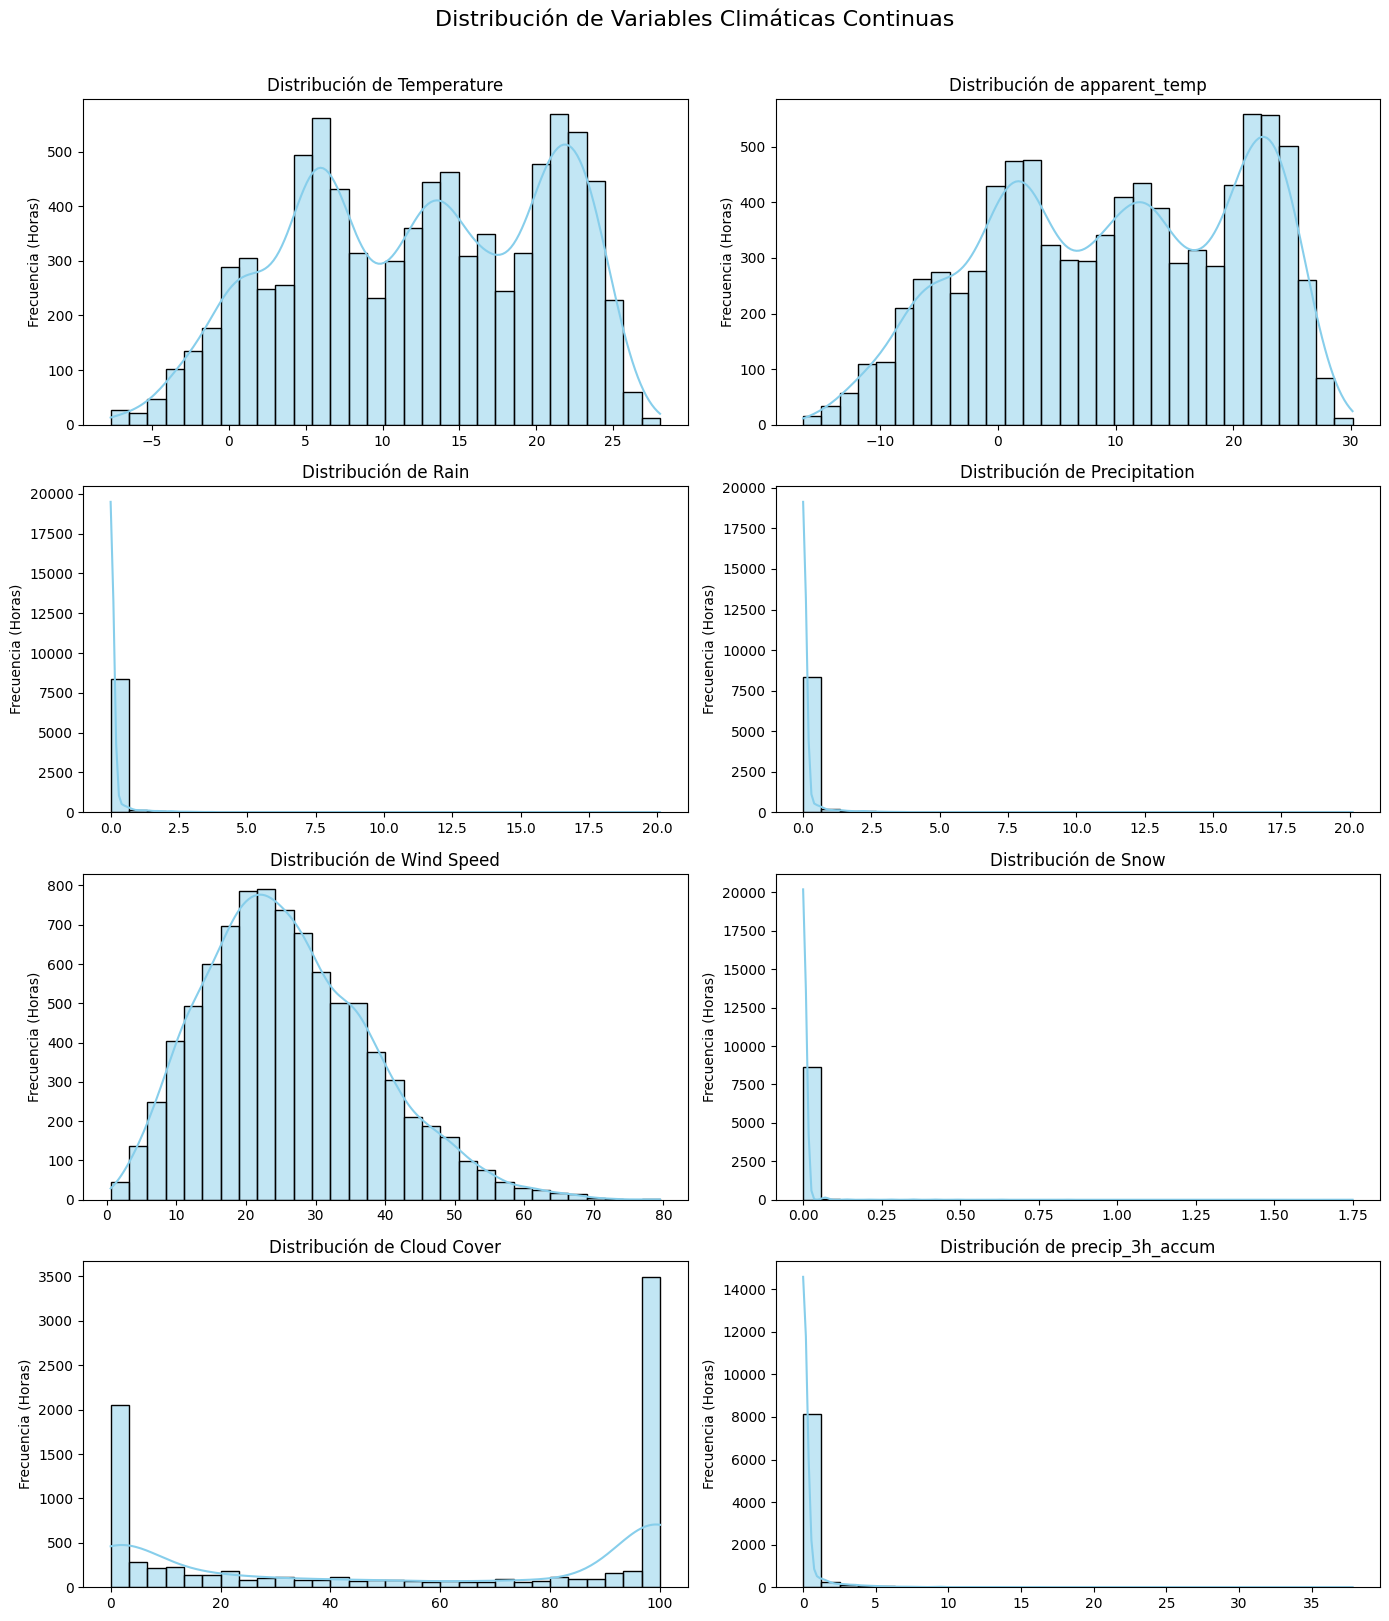

In [8]:
vars_continuas = [
    'Temperature', 'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed', 'Snow', 'Cloud Cover', 'precip_3h_accum'
]

ncols = 2
nrows = 4

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 16))
fig.suptitle('Distribución de Variables Climáticas Continuas', fontsize=16, y=1.01)

axes = axes.flatten()

# Bucle para dibujar cada variable
for i, var in enumerate(vars_continuas):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia (Horas)')

plt.tight_layout()
plt.show()

### Boxplots para detectar outliers

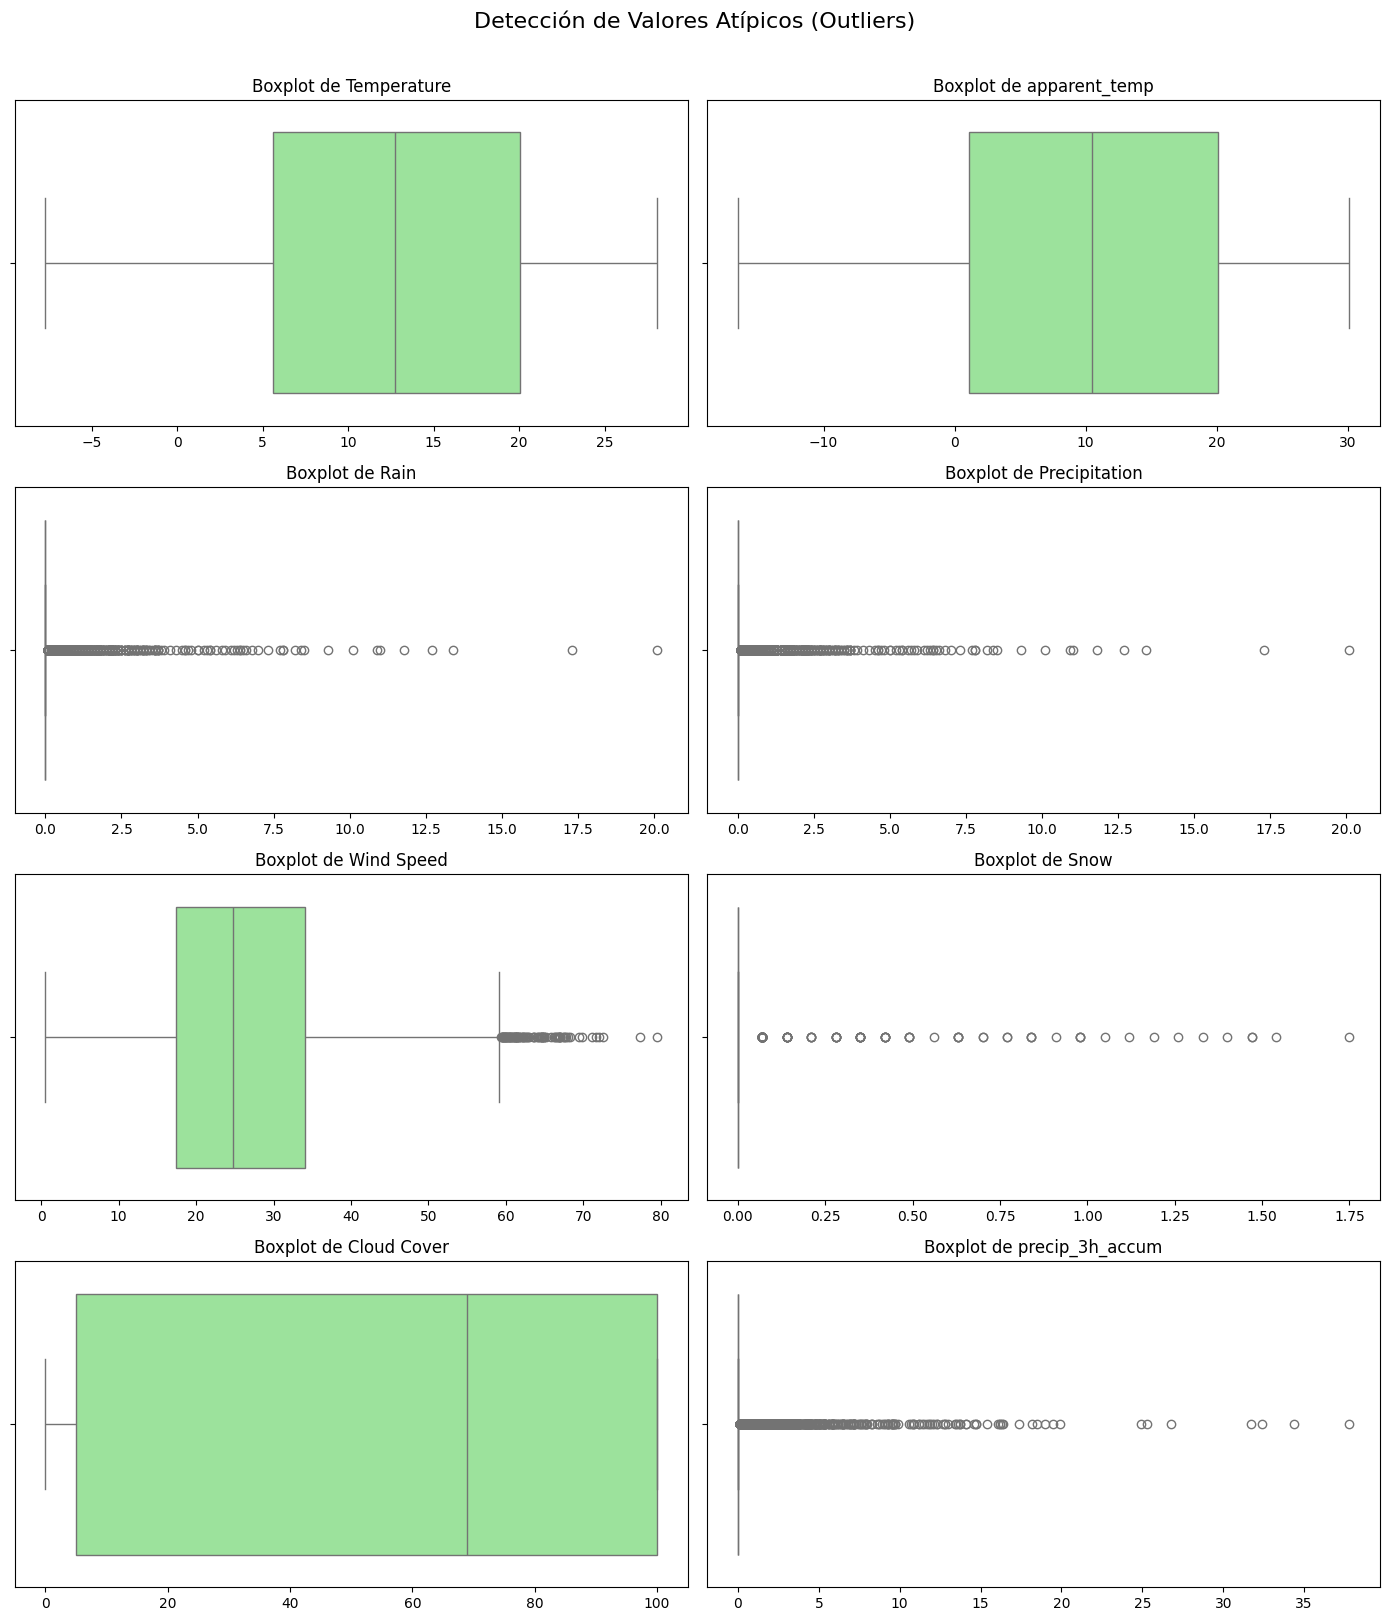

In [9]:
vars_continuas = [
    'Temperature', 'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed', 'Snow', 'Cloud Cover', 'precip_3h_accum'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Detección de Valores Atípicos (Outliers)', fontsize=16, y=1.01)

axes = axes.flatten()

for i, var in enumerate(vars_continuas):
    sns.boxplot(x=df[var], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot de {var}', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Frecuencia de las variables binarias 

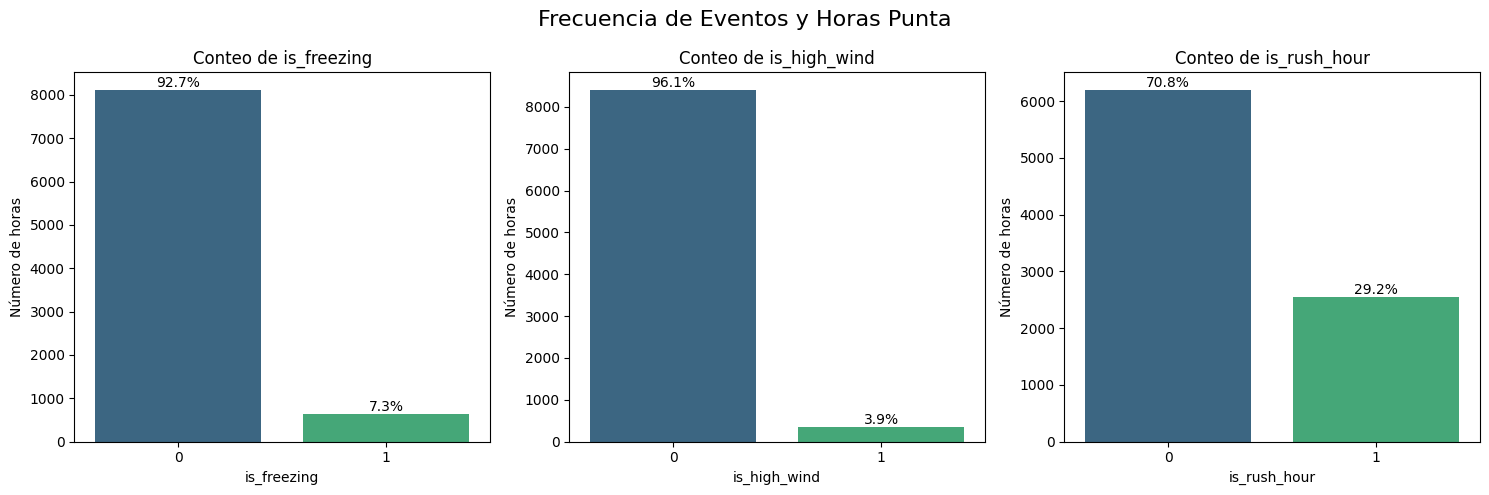

In [10]:
vars_binarias = ['is_freezing', 'is_high_wind', 'is_rush_hour']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Frecuencia de Eventos y Horas Punta', fontsize=16)

for i, var in enumerate(vars_binarias):
    sns.countplot(x=var, data=df, ax=axes[i], palette='viridis', hue=var, legend=False)
    
    axes[i].set_title(f'Conteo de {var}')
    axes[i].set_ylabel('Número de horas')
    
    total = len(df[var])
    for p in axes[i].patches:
        porcentaje = f'{100 * p.get_height() / total:.1f}%'
        axes[i].annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Análisis bivariante (Relaciones entre variables predictoras)

### Matriz de correlación (variables numéricas: continuas y binarias)

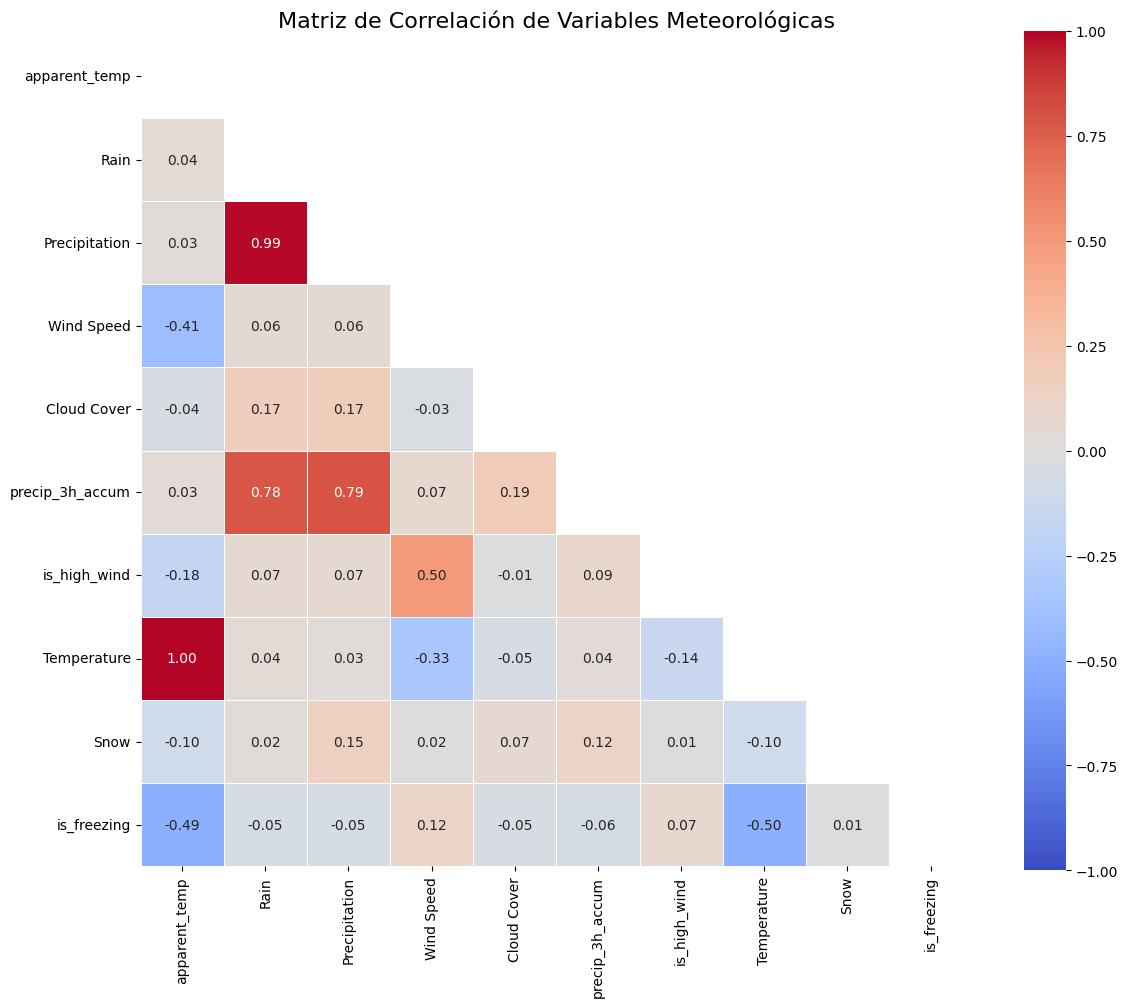

In [11]:
vars_numericas = [
    'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed',  'Cloud Cover', 'precip_3h_accum',
    'is_high_wind', 'Temperature', 'Snow','is_freezing'

] 

matriz_corr = df[vars_numericas].corr()

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación de Variables Meteorológicas', fontsize=16)

sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            annot_kws={"size": 10})

plt.tight_layout()
plt.show()

### Análisis de colinealidad: pares con correlación |r| > 0.85

In [12]:
corr_unstacked = matriz_corr.abs().unstack()

# Filtramos las que son mayores a 0.85 pero menores a 1.0 (para que no salga Temperatura vs Temperatura)
alta_corr = corr_unstacked[(corr_unstacked > 0.85) & (corr_unstacked < 1.0)]

if alta_corr.empty:
    print("No se encontraron variables altamente correlacionadas.")
else:
    display(alta_corr.drop_duplicates().to_frame(name='Correlación'))

,,Correlación
apparent_temp,Temperature,0.995765
Rain,Precipitation,0.991566


## Relación con la variable a predecir

### Cargamos los dataset de trenes

In [13]:
print("--- 1. Identificando los días clave ---")
# Extraemos una lista de las fechas únicas donde hubo clima extremo
fechas_extremas = df_extremos['Date'].dt.strftime('%Y-%m-%d').unique()

print(f"Se han detectado {len(fechas_extremas)} días con clima extremo en todo el año.")
print(f"Fechas a descargar: {fechas_extremas[:5]}... (mostrando las 5 primeras)")

print("\n--- 2. Descargando SOLO los trenes de esos días ---")
lista_trenes_extremos = []

for date in fechas_extremas:
    ruta_trenes = f"grupo5/cleaned/gtfs_clean_scheduled/date={date}/gtfs_scheduled_{date}.parquet"
    
    try:
        # Descargamos el archivo de trenes SÓLO para este día conflictivo
        df_dia_tren = download_df_parquet(access_key, secret_key, ruta_trenes)
        
        if df_dia_tren is not None and not df_dia_tren.empty:
            
            # Ya que tenemos el día entero, vamos a quedarnos solo con las horas exactas que fueron extremas ese día
            horas_malas = df_extremos[df_extremos['Date'].dt.strftime('%Y-%m-%d') == date]['hour'].unique()
            
            # Calculamos la hora en el df de trenes y filtramos
            df_dia_tren['hour'] = (df_dia_tren['actual_seconds'] // 3600).fillna(-1).astype(int)
            df_dia_tren = df_dia_tren[df_dia_tren['hour'].isin(horas_malas)]
            
            # Añadimos a la lista
            lista_trenes_extremos.append(df_dia_tren)
            print(f"✓ Día {date} descargado y filtrado por horas extremas.")
            
    except Exception as e:
        # Si ese día no hay datos de trenes, lo saltamos
        print(f"✗ Error o sin datos en trenes para {date}")
        pass

if len(lista_trenes_extremos) > 0:
    df_trenes_extremo = pd.concat(lista_trenes_extremos, ignore_index=True)
    
    # Cruzamos (Merge) con df_extremo para añadirle las columnas de Lluvia, Temperatura, etc.
    df_trenes_extremo['Date'] = pd.to_datetime(df_trenes_extremo['service_date']).dt.tz_localize(None)
    df_merged_extremo = pd.merge(df_trenes_extremo, df_extremos, on=['Date', 'hour'], how='inner')
    
else:
    print("\nNo se pudo descargar ningún tren para esas fechas.")

--- 1. Identificando los días clave ---
Se han detectado 156 días con clima extremo en todo el año.
Fechas a descargar: <ArrowStringArray>
['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05']
Length: 5, dtype: str... (mostrando las 5 primeras)

--- 2. Descargando SOLO los trenes de esos días ---
✓ Día 2025-01-01 descargado y filtrado por horas extremas.
✓ Día 2025-01-02 descargado y filtrado por horas extremas.
✓ Día 2025-01-03 descargado y filtrado por horas extremas.
✓ Día 2025-01-04 descargado y filtrado por horas extremas.
✓ Día 2025-01-05 descargado y filtrado por horas extremas.
✓ Día 2025-01-06 descargado y filtrado por horas extremas.
✓ Día 2025-01-07 descargado y filtrado por horas extremas.
✓ Día 2025-01-08 descargado y filtrado por horas extremas.
✓ Día 2025-01-09 descargado y filtrado por horas extremas.
✓ Día 2025-01-10 descargado y filtrado por horas extremas.
✓ Día 2025-01-11 descargado y filtrado por horas extremas.
✓ Día 2025-01-13 descargado y filtra

In [14]:
df_merged_extremo['Date']

0        2025-01-02
1        2025-01-02
2        2025-01-02
3        2025-01-02
4        2025-01-02
            ...    
135767   2025-12-31
135768   2025-12-31
135769   2025-12-31
135770   2025-12-31
135771   2025-12-31
Name: Date, Length: 135772, dtype: datetime64[us]

### Temperatura frente a colapsos (más de 10 min de retraso)

C:\Users\ivang\AppData\Local\Temp\ipykernel_29124\2104896490.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


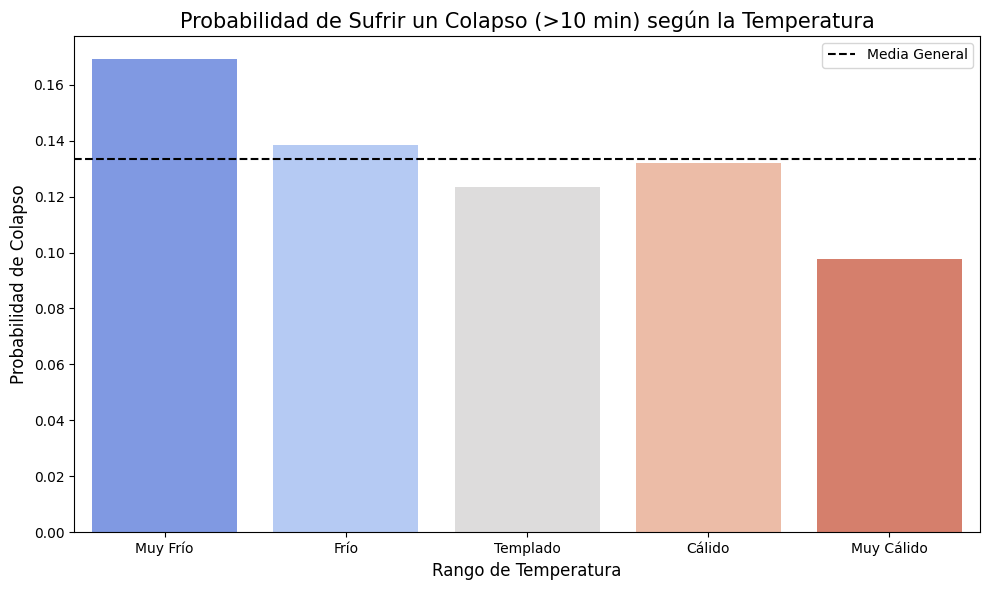

In [15]:
# Definimos qué es un colapso (ej: más de 10 min de retraso)
df_merged_extremo['retraso_critico'] = (df_merged_extremo['delay_minutes'] > 10).astype(int)

# Dividimos la Temperatura en 5 grupos iguales (del más frío al más cálido)
df_merged_extremo['temp_bins'] = pd.qcut(
    df_merged_extremo['Temperature'], 
    q=5, 
    labels=['Muy Frío', 'Frío', 'Templado', 'Cálido', 'Muy Cálido']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_merged_extremo, 
    x='temp_bins', 
    y='retraso_critico', 
    palette='coolwarm', 
    errorbar=None
)

# Añadimos la media general como referencia
plt.axhline(df_merged_extremo['retraso_critico'].mean(), color='black', linestyle='--', label='Media General')

plt.title('Probabilidad de Sufrir un Colapso (>10 min) según la Temperatura', fontsize=15)
plt.ylabel('Probabilidad de Colapso', fontsize=12)
plt.xlabel('Rango de Temperatura', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Conclusión: La probabilidad de sufrir un colapso (>10 min) es mayor en condiciones de mucho frío, situándose claramente por encima de la media general. A medida que la temperatura aumenta hacia rangos templados y cálidos, la probabilidad tiende a disminuir, lo que sugiere que las temperaturas bajas tienen un mayor impacto en la ocurrencia de retrasos severos.

### Importancia relativa de las variables

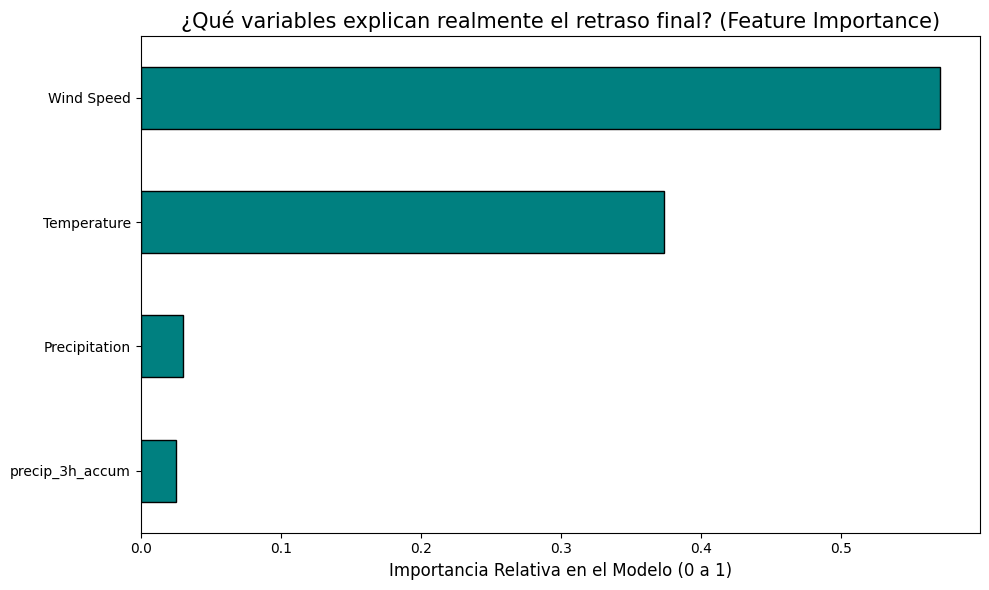

In [16]:
#Las variables que parecen más prometedoras
features = ['Temperature', 'Precipitation', 'Wind Speed', 'precip_3h_accum']

target = 'target_delay_end'

#Limpiamos nulos y sacamos una muestra de 50.000 filas para que se ejecute en 2 segundos
df_rf = df_merged_extremo.dropna(subset=features + [target]).sample(n=min(50000, len(df_merged_extremo)), random_state=42)

#Entrenamos un bosque aleatorio pequeño
rf = RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(df_rf[features], df_rf[target])

#Extraemos y graficamos la importancia de las variables
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='teal', edgecolor='black')
plt.title('¿Qué variables explican realmente el retraso final? (Feature Importance)', fontsize=15)
plt.xlabel('Importancia Relativa en el Modelo (0 a 1)', fontsize=12)
plt.tight_layout()
plt.show()

Conclusión: La variable que más explica el retraso final en el modelo es la temperatura, seguida a bastante distancia por la velocidad del viento. En cambio, las variables relacionadas con la precipitación (lluvia y acumulado en 3 horas) tienen un peso mucho menor.

### Occurencia de un evento extremo frente a retraso

In [17]:
# Banderas de clima extremo (0/1)
df_merged_extremo['is_flooding_risk'] = (df_merged_extremo['precip_3h_accum'] > 1).astype(int)
df_merged_extremo['is_extreme_heat'] = (df_merged_extremo['Temperature'] > 7.0).astype(int)
df_merged_extremo['is_blizzard'] = ((df_merged_extremo['Snow'] > 0) & (df_merged_extremo['Wind Speed'] > 25)).astype(int)

# Media de delay_minutes agrupada por riesgo de inundación
delay_por_flooding = (
    df_merged_extremo.groupby('is_flooding_risk', dropna=False)['delay_minutes']
    .mean()
    .rename('avg_delay_minutes')
)
display(delay_por_flooding.to_frame())

# Media de delay_minutes agrupada por riesgo de calor extremo
delay_por_extreme_heat = (
    df_merged_extremo.groupby('is_extreme_heat', dropna=False)['delay_minutes']
    .mean()
    .rename('avg_delay_minutes')
)
display(delay_por_extreme_heat.to_frame())

# Media de delay_minutes agrupada por riesgo de blizzard
delay_por_blizzard = (
    df_merged_extremo.groupby('is_blizzard', dropna=False)['delay_minutes']
    .mean()
    .rename('avg_delay_minutes')
)
display(delay_por_blizzard.to_frame())

,avg_delay_minutes
is_flooding_risk,
0,4.180839
1,3.139081


,avg_delay_minutes
is_extreme_heat,
0,4.294901
1,3.597051


,avg_delay_minutes
is_blizzard,
0,4.013050
1,4.524971


Conclusión: Los resultados muestran que ni el riesgo de inundación ni el calor extremo parecen aumentar el retraso medio; de hecho, en ambos casos el retraso promedio es ligeramente menor cuando la bandera es 1. En cambio, el blizzard (nieve + viento fuerte) sí está asociado a un aumento del retraso medio (4.52 vs 4.01 minutos), lo que sugiere que las condiciones combinadas de nieve y viento intenso tienen un impacto más claro en la operación que la lluvia acumulada o el calor moderado.

### Comparación de la distribución del retraso en líneas exteriores frente a subterráneas en presencia de nieve

C:\Users\ivang\AppData\Local\Temp\ipykernel_29124\463507824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


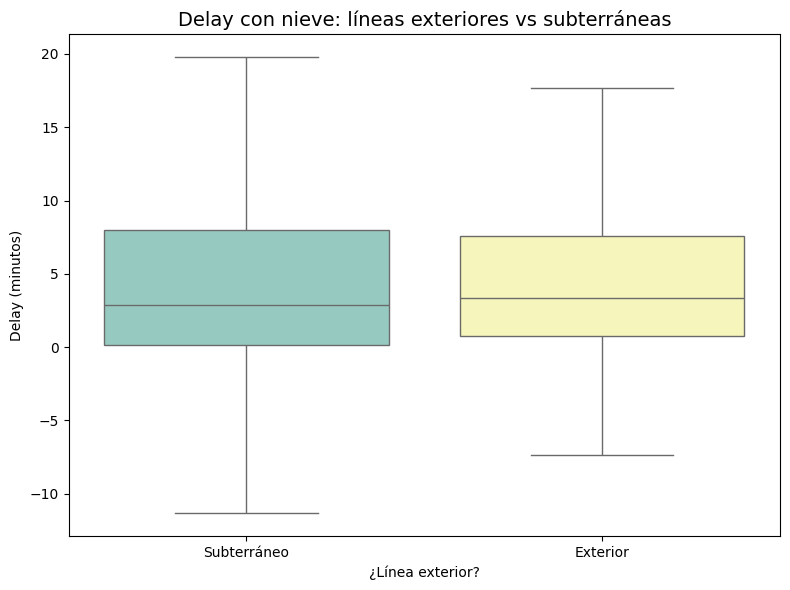

In [18]:
lineas_exteriores = ['7', 'N', 'Q', 'J', 'Z', 'B', 'D']

# True si la línea tiene mucho tramo exterior
df_merged_extremo['is_exterior'] = df_merged_extremo['route_id'].astype(str).isin(lineas_exteriores)

# Filtramos solo observaciones con nieve
df_snow = df_merged_extremo[df_merged_extremo['Snow'] > 0].copy()

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_snow,
    x='is_exterior',
    y='delay_minutes',
    showfliers=False,
    palette='Set3'
 )
plt.title('Delay con nieve: líneas exteriores vs subterráneas', fontsize=14)
plt.xlabel('¿Línea exterior?')
plt.ylabel('Delay (minutos)')
plt.xticks([0, 1], ['Subterráneo', 'Exterior'])
plt.tight_layout()
plt.show()

### Comparación de la distribución del retraso en líneas exteriores frente a subterráneas en presencia de lluvia

C:\Users\ivang\AppData\Local\Temp\ipykernel_29124\2235381513.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


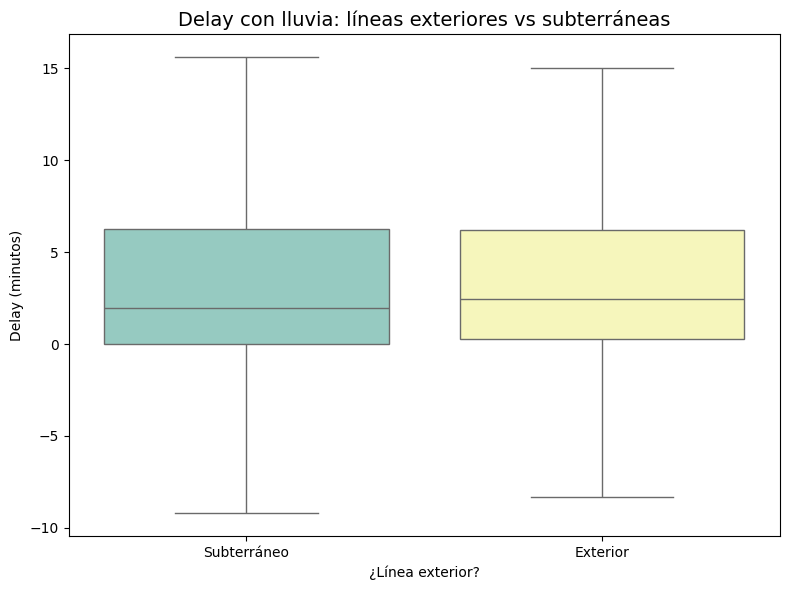

In [19]:
lineas_exteriores = ['7', 'N', 'Q', 'J', 'Z', 'B', 'D']

# True si la línea tiene mucho tramo exterior
df_merged_extremo['is_exterior'] = df_merged_extremo['route_id'].astype(str).isin(lineas_exteriores)

# Filtramos solo observaciones con nieve
df_rain = df_merged_extremo[df_merged_extremo['Precipitation'] > 0].copy()

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_rain,
    x='is_exterior',
    y='delay_minutes',
    showfliers=False,
    palette='Set3'
 )
plt.title('Delay con lluvia: líneas exteriores vs subterráneas', fontsize=14)
plt.xlabel('¿Línea exterior?')
plt.ylabel('Delay (minutos)')
plt.xticks([0, 1], ['Subterráneo', 'Exterior'])
plt.tight_layout()
plt.show()

### Comparación de la distribución del retraso en líneas exteriores frente a subterráneas en presencia de viento fuerte

C:\Users\ivang\AppData\Local\Temp\ipykernel_29124\869386958.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


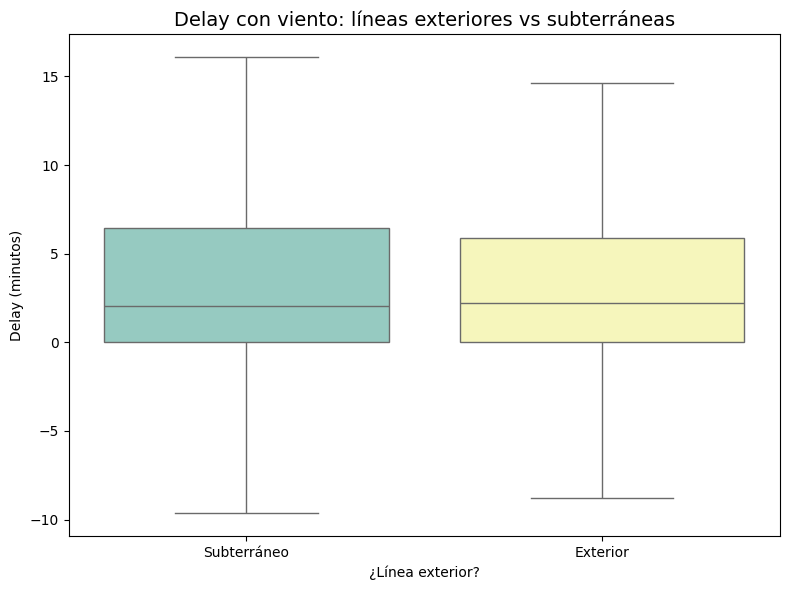

In [20]:
lineas_exteriores = ['7', 'N', 'Q', 'J', 'Z', 'B', 'D']

# True si la línea tiene mucho tramo exterior
df_merged_extremo['is_exterior'] = df_merged_extremo['route_id'].astype(str).isin(lineas_exteriores)

# Filtramos solo observaciones con viento
df_wind = df_merged_extremo[df_merged_extremo['Wind Speed'] > 0].copy()

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_wind,
    x='is_exterior',
    y='delay_minutes',
    showfliers=False,
    palette='Set3'
 )
plt.title('Delay con viento: líneas exteriores vs subterráneas', fontsize=14)
plt.xlabel('¿Línea exterior?')
plt.ylabel('Delay (minutos)')
plt.xticks([0, 1], ['Subterráneo', 'Exterior'])
plt.tight_layout()
plt.show()

Conclusión: En las tres condiciones (nieve, lluvia y viento), no se observan diferencias estructurales grandes entre líneas exteriores y subterráneas.
Las medianas son muy similares y las distribuciones presentan una dispersión comparable, lo que sugiere que el tipo de línea (exterior vs subterránea) no parece modificar drásticamente el retraso medio bajo estas condiciones climáticas.
Si hay alguna diferencia, es leve y más relacionada con la variabilidad que con un cambio claro en el retraso central.

### Delta a 30 minutos en lluvia frente a clima seco

,avg_delta_delay_30m
condicion_clima,
Seco,-111.944069
Lluvia,-110.708119


C:\Users\ivang\AppData\Local\Temp\ipykernel_29124\2919033561.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


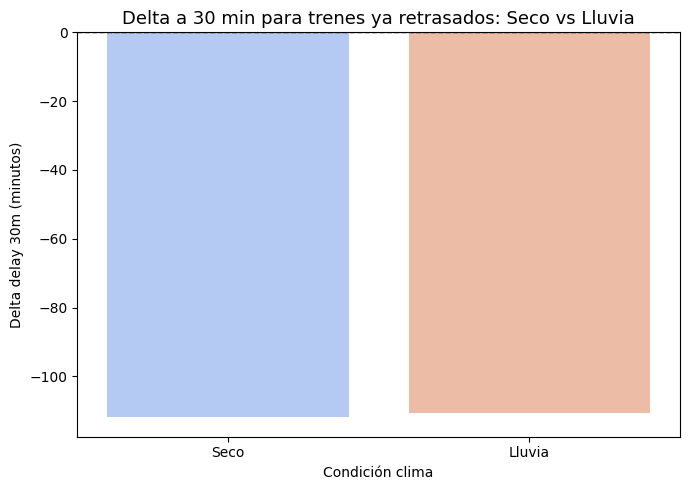

In [21]:
# Creamos/normalizamos condición climática: Seco vs Lluvia
df_merged_extremo


df_merged_extremo['condicion_clima'] = np.where(df_merged_extremo['Precipitation'] > 0, 'Lluvia', 'Seco')

# Filtramos trenes que ya van tarde
df_tarde = df_merged_extremo[df_merged_extremo['delay_minutes'] > 2].copy()

# Media de delta_delay_30m por condición climática
delta_por_clima = (
    df_tarde.groupby('condicion_clima', dropna=False)['delta_delay_30m']
    .mean()
    .reindex(['Seco', 'Lluvia'])
    .rename('avg_delta_delay_30m')
)
display(delta_por_clima.to_frame())

plt.figure(figsize=(7, 5))
sns.barplot(
    x=delta_por_clima.index,
    y=delta_por_clima.values,
    palette='coolwarm',
    errorbar=None
 )
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Delta a 30 min para trenes ya retrasados: Seco vs Lluvia', fontsize=13)
plt.xlabel('Condición clima')
plt.ylabel('Delta delay 30m (minutos)')
plt.tight_layout()
plt.show()

Conclusión: La gráfica muestra que, para trenes que ya iban retrasados, el delta a 30 minutos es igual de negativo en condiciones de lluvia que en seco. Esto indica que, bajo lluvia, el retraso no tiende tiende a incrementarse más en los siguientes 30 minutos en comparación con condiciones secas.

### Efecto de la temperatura extrema sobre el retraso a corto plazo

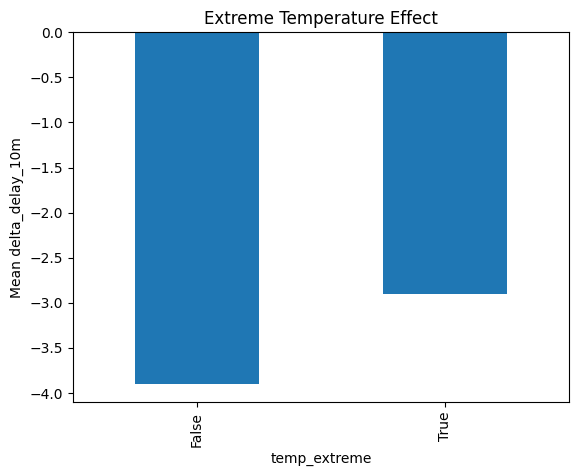

In [22]:
df = df_merged_extremo.copy()

low = df["Temperature"].quantile(0.1)
high = df["Temperature"].quantile(0.9)

df["temp_extreme"] = (df["Temperature"] < low) | (df["Temperature"] > high)

mean_delta = df.groupby("temp_extreme")["delta_delay_10m"].mean()

plt.figure()
mean_delta.plot(kind="bar")
plt.ylabel("Mean delta_delay_10m")
plt.title("Extreme Temperature Effect")
plt.show()

Conclusión: La gráfica muestra que cuando hay temperatura extrema (True), el delta_delay_10m medio es menos negativo que en condiciones normales.
Esto sugiere que, bajo temperaturas extremas, el retraso no tiende a empeorar en los siguientes 10 minutos en comparación con situaciones de temperatura no extrema.

### ------------------------------------------------------------------------------------------------------------------------------------

(A partir de aquí se ve la falta de relación lineal directa entre el clima y el retraso en los trenes de forma más evidente)

### Matriz de correlación

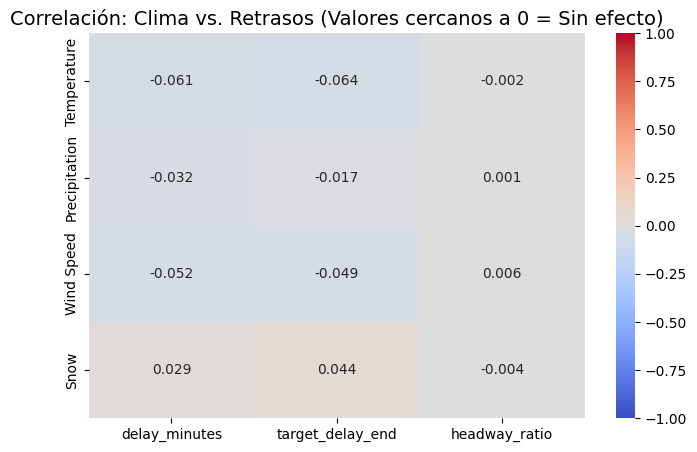

In [23]:
# Seleccionamos las variables del clima y las de retraso
cols_clima = ['Temperature', 'Precipitation', 'Wind Speed', 'Snow']
cols_trenes = ['delay_minutes', 'target_delay_end', 'headway_ratio']

# Calculamos la correlación solo entre estos dos grupos
corr_matrix = df_merged_extremo[cols_clima + cols_trenes].corr().loc[cols_clima, cols_trenes]

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, vmax=1,
    fmt=".3f"
)
plt.title('Correlación: Clima vs. Retrasos (Valores cercanos a 0 = Sin efecto)', fontsize=14)
plt.show()

Conclusión: La matriz de correlaciones muestra que todas las relaciones entre variables climáticas y retrasos son muy cercanas a cero, lo que indica una ausencia de relación lineal fuerte.

Aunque la temperatura presenta las correlaciones negativas más altas (alrededor de -0.06), y la nieve ligeras correlaciones positivas (~0.04), los valores son demasiado pequeños para sugerir un impacto significativo. En conjunto, el clima parece tener un efecto lineal muy débil o prácticamente nulo sobre los retrasos y el headway_ratio.

### Combinación de variables climáticas frente a retraso (en corto, medio y más largo plazo)

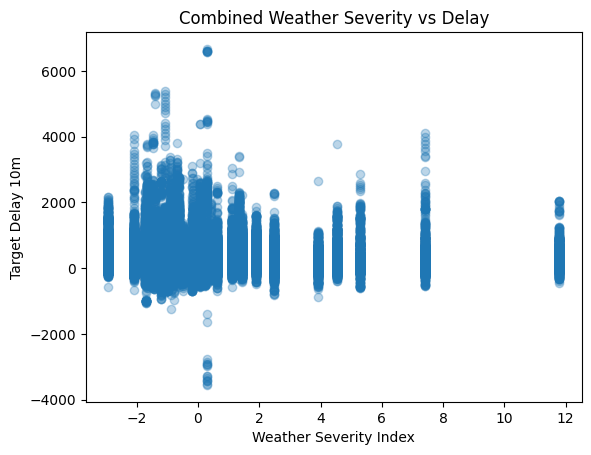

In [24]:
# Normalizamos variables
df = df_merged_extremo.copy()

weather_vars = ['Precipitation', 'precip_3h_accum', 'Wind Speed', 'Snow']

for col in weather_vars:
    df[col+'_norm'] = (df[col] - df[col].mean()) / df[col].std()

# Índice combinado
df['weather_severity_index'] = (
    df['Precipitation_norm'] +
    df['precip_3h_accum_norm'] +
    df['Wind Speed_norm'] +
    df['Snow_norm']
)

plt.figure()
plt.scatter(df['weather_severity_index'], df['target_delay_10m'], alpha=0.3)

m, b = np.polyfit(df['weather_severity_index'], df['target_delay_10m'], 1)
plt.plot(df['weather_severity_index'],
         m*df['weather_severity_index'] + b)

plt.xlabel("Weather Severity Index")
plt.ylabel("Target Delay 10m")
plt.title("Combined Weather Severity vs Delay")
plt.show()

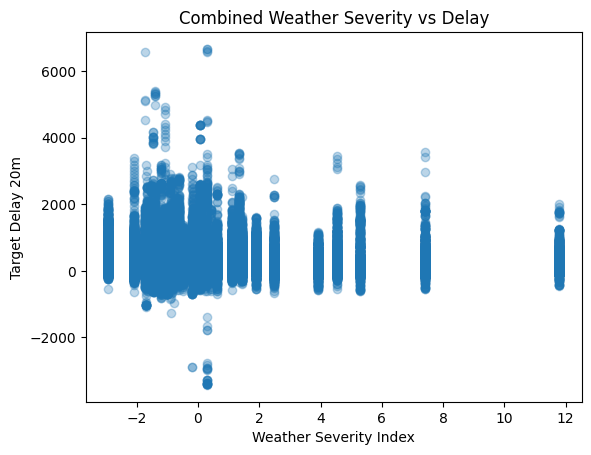

In [25]:
# Normalizamos variables
df = df_merged_extremo.copy()

weather_vars = ['Precipitation', 'precip_3h_accum', 'Wind Speed', 'Snow']

for col in weather_vars:
    df[col+'_norm'] = (df[col] - df[col].mean()) / df[col].std()

# Índice combinado
df['weather_severity_index'] = (
    df['Precipitation_norm'] +
    df['precip_3h_accum_norm'] +
    df['Wind Speed_norm'] +
    df['Snow_norm']
)

plt.figure()
plt.scatter(df['weather_severity_index'], df['target_delay_20m'], alpha=0.3)

m, b = np.polyfit(df['weather_severity_index'], df['target_delay_20m'], 1)
plt.plot(df['weather_severity_index'],
         m*df['weather_severity_index'] + b)

plt.xlabel("Weather Severity Index")
plt.ylabel("Target Delay 20m")
plt.title("Combined Weather Severity vs Delay")
plt.show()

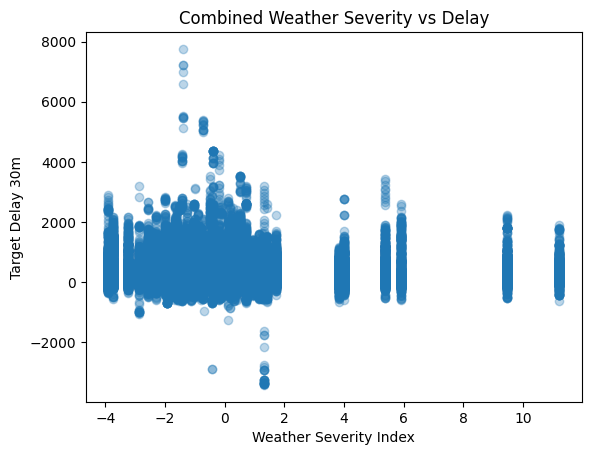

In [26]:
# Normalizamos variables
df = df_merged_extremo.copy()

weather_vars = ['Precipitation', 'precip_3h_accum', 'Wind Speed', 'Snow', 'Temperature']

for col in weather_vars:
    df[col+'_norm'] = (df[col] - df[col].mean()) / df[col].std()

# Índice combinado
df['weather_severity_index'] = (
    df['Precipitation_norm'] +
    df['precip_3h_accum_norm'] +
    df['Wind Speed_norm'] +
    df['Snow_norm'] +
    df['Temperature_norm']
)

plt.figure()
plt.scatter(df['weather_severity_index'], df['target_delay_30m'], alpha=0.3)

m, b = np.polyfit(df['weather_severity_index'], df['target_delay_30m'], 1)
plt.plot(df['weather_severity_index'],
         m*df['weather_severity_index'] + b)

plt.xlabel("Weather Severity Index")
plt.ylabel("Target Delay 30m")
plt.title("Combined Weather Severity vs Delay")
plt.show()

Conclusión: En los tres gráficos (target_delay_10m, 20m y 30m) no se observa una tendencia clara ni una relación lineal evidente entre el índice combinado de severidad climática y el retraso. Es decir, incluso combinando variables climáticas en un índice de severidad, el clima por sí solo no explica de forma fuerte ni sistemática la magnitud del retraso a 10, 20 o 30 minutos.

### Gravedad de lluvia a hora punta frente a retraso

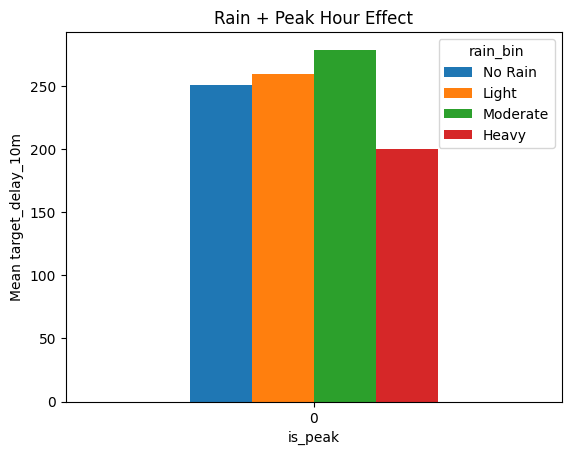

In [27]:
df = df_merged_extremo.copy()

if 'is_peak' not in df.columns:
    raise KeyError("Falta la columna 'is_peak' en df_merged_extremo")

# Crear rain_bin si no existe
if 'rain_bin' not in df.columns:
    # usa precip_3h_accum o Precipitation (elige una)
    rain_source = 'precip_3h_accum' if 'precip_3h_accum' in df.columns else 'Precipitation'
    bins = [-0.001, 0, 0.5, 2, 10, float('inf')]
    labels = ["No Rain", "Light", "Moderate", "Heavy", "Extreme"]
    df['rain_bin'] = pd.cut(df[rain_source], bins=bins, labels=labels)

# Quitar filas sin grupo o sin target
df_plot = df.dropna(subset=['rain_bin', 'is_peak', 'target_delay_10m'])

mean_combo = df_plot.groupby(['is_peak', 'rain_bin'])['target_delay_10m'].mean().unstack()

ax = mean_combo.plot(kind='bar')
ax.set_ylabel("Mean target_delay_10m")
ax.set_title("Rain + Peak Hour Effect")
plt.xticks(rotation=0)
plt.show()

Conclusión: La gráfica sugiere que, en hora punta, el retraso medio aumenta ligeramente conforme se intensifica la lluvia (de “No Rain” a “Moderate”), lo que indica un posible efecto acumulativo entre congestión y precipitación. En lluvia extrema, el retraso baja, probablemente porque los ciudadanos salgan menos de casa.

### Lluvia o no frente a retraso

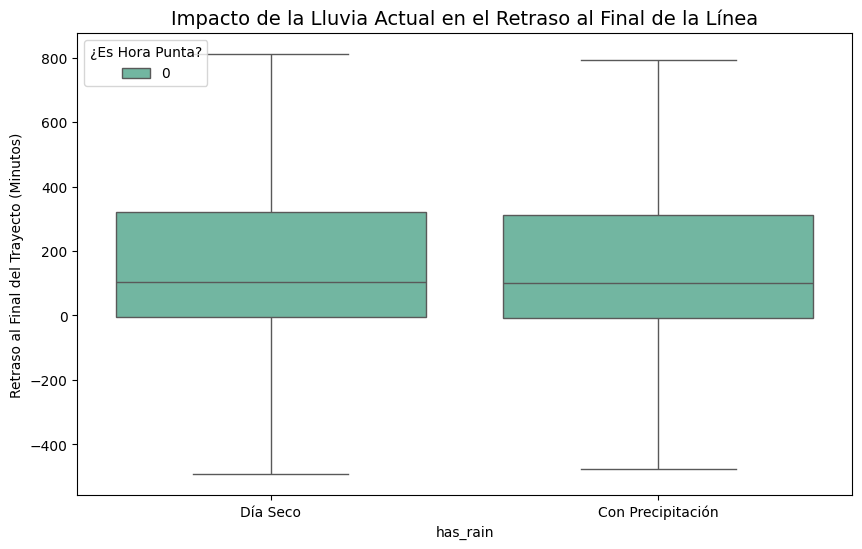

In [28]:
df_plot = df_merged_extremo.dropna(subset=['target_delay_end']).copy()
df_plot['has_rain'] = df_plot['Precipitation'] > 0

plt.figure(figsize=(10, 6))
# Usamos un boxplot sin outliers extremos (showfliers=False) para ver la mediana claramente
sns.boxplot(
    data=df_plot, 
    x='has_rain', 
    y='target_delay_end', 
    hue='is_peak', 
    palette='Set2', 
    showfliers=False
)

plt.title('Impacto de la Lluvia Actual en el Retraso al Final de la Línea', fontsize=14)
plt.ylabel('Retraso al Final del Trayecto (Minutos)')
plt.xticks([0, 1], ['Día Seco', 'Con Precipitación'])
plt.legend(title='¿Es Hora Punta?', loc='upper left')
plt.show()

Conclusión: La distribución del retraso final es muy similar entre días secos y días con precipitación. Las medianas prácticamente coinciden y la dispersión (rango intercuartílico y extremos) es comparable en ambos casos.

Esto sugiere que la presencia de lluvia, por sí sola, no parece generar un aumento claro ni estructural en el retraso al final de la línea.

### Distribuciones de lluvia vs retraso y temperatura vs retraso

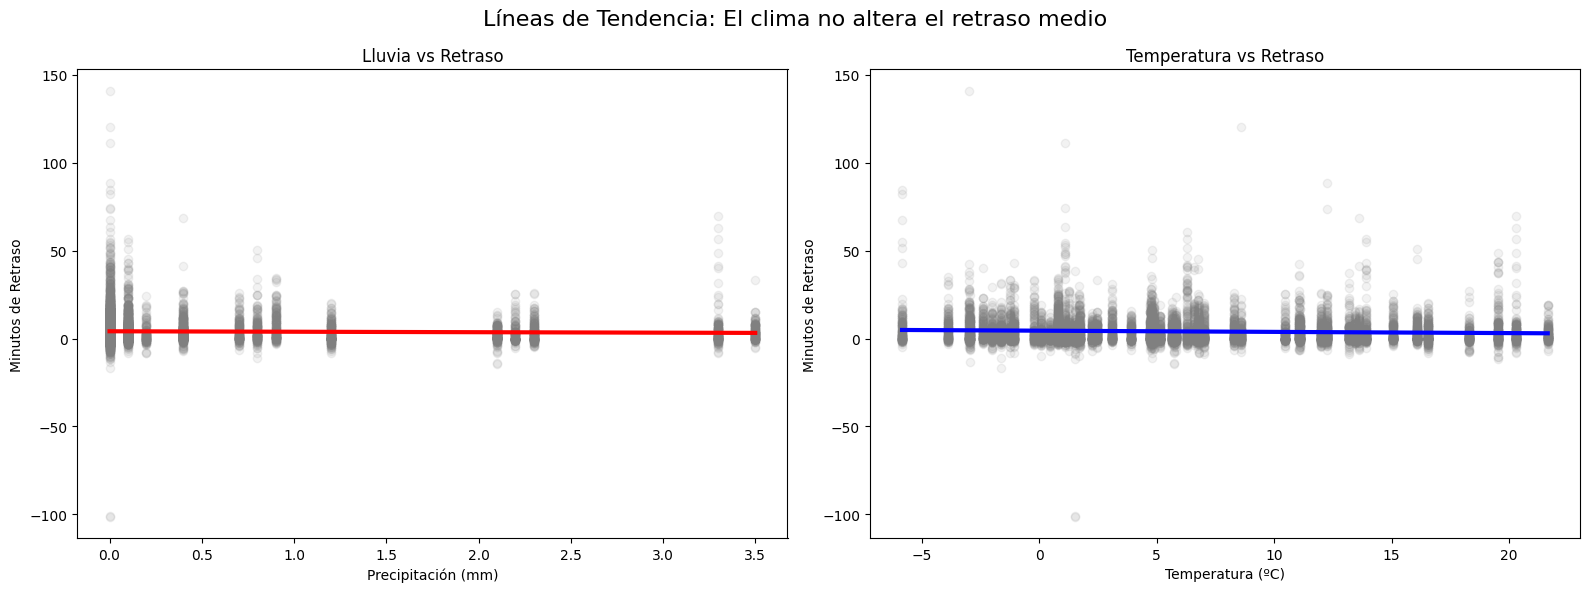

In [29]:
# Hacemos una muestra de 10,000 puntos para que el gráfico cargue rápido
df_sample = df_merged_extremo.dropna(subset=['Precipitation', 'delay_minutes']).sample(n=min(10000, len(df_merged_extremo)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Líneas de Tendencia: El clima no altera el retraso medio', fontsize=16)

# Gráfico 1: Lluvia vs Retraso
sns.regplot(
    data=df_sample, 
    x='Precipitation', 
    y='delay_minutes', 
    ax=axes[0], 
    scatter_kws={'alpha': 0.1, 'color': 'gray'}, 
    line_kws={'color': 'red', 'linewidth': 3}
)
axes[0].set_title('Lluvia vs Retraso')
axes[0].set_xlabel('Precipitación (mm)')
axes[0].set_ylabel('Minutos de Retraso')

# Gráfico 2: Temperatura vs Retraso
sns.regplot(
    data=df_sample, 
    x='Temperature', 
    y='delay_minutes', 
    ax=axes[1], 
    scatter_kws={'alpha': 0.1, 'color': 'gray'}, 
    line_kws={'color': 'blue', 'linewidth': 3}
)
axes[1].set_title('Temperatura vs Retraso')
axes[1].set_xlabel('Temperatura (ºC)')
axes[1].set_ylabel('Minutos de Retraso')

plt.tight_layout()
plt.show()

Conclusión: Las líneas de tendencia en ambos gráficos son prácticamente planas, lo que indica que ni la precipitación ni la temperatura muestran una relación lineal clara con el retraso medio.

Aunque existe una gran dispersión en los datos, el retraso promedio se mantiene estable a lo largo de distintos niveles de lluvia y temperatura.